In [1]:
import numpy as np
import numerik as nu
import matplotlib.pyplot as plt


Aufgabe 1 Kondition

![Serie15_Aufgabe 1.jpeg](<attachment:Serie15_Aufgabe 1.jpeg>)
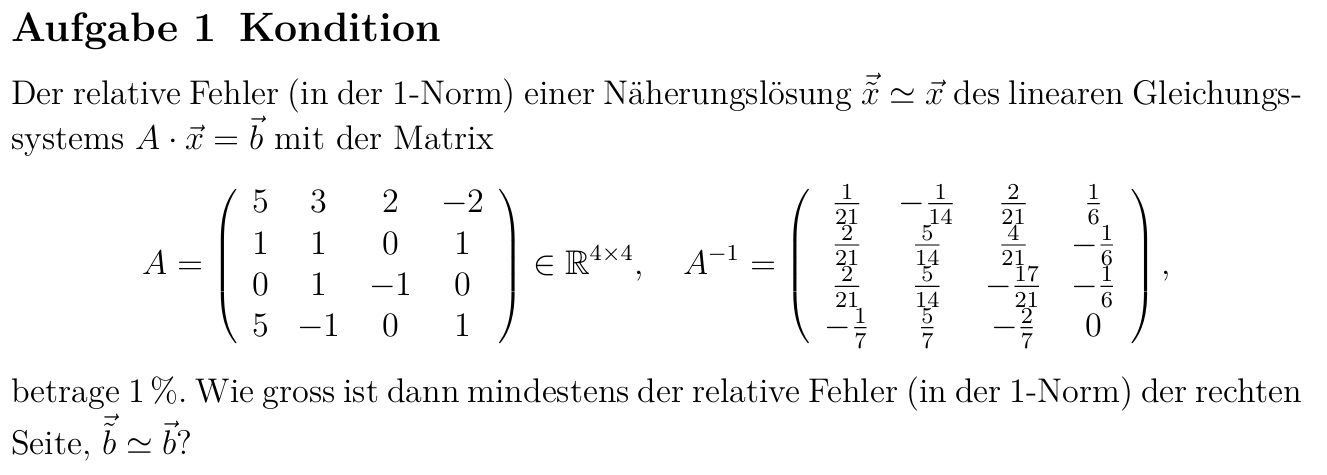

In [2]:
# Matrix A definieren
A = np.array([
    [5, 3, 2, -2],
    [1, 1 , 0, 1],
    [0, 1, -1, 0],
    [5, -1, 0, 1],
], dtype = float)

# Inverse Matrix berechnen
A_inv = np.linalg.inv(A)

# 1-Normen von A und A_inv berechnen
norm_A = np.linalg.norm(A, 1)
norm_A_inv = np.linalg.norm(A_inv, 1)

# Konditionszahl berechnen Krelativ
k_relativ = norm_A * norm_A_inv
print(f"K-Relativ: {k_relativ:.2e}")

# relativer Fehler von x berechnen
rel_x = 0.01 # relativer Fehler = 1%

# realtiver Fehler von b berechnen
rel_b = rel_x / k_relativ
print(f"Relativer Fehler von b: {rel_b:.2e}")

K-Relativ: 1.65e+01
Relativer Fehler von b: 6.06e-04


Aufgabe - 2 lineares Randwertproblem

![Serie15_Aufgabe 2.png](<attachment:Serie15_Aufgabe 2.png>)
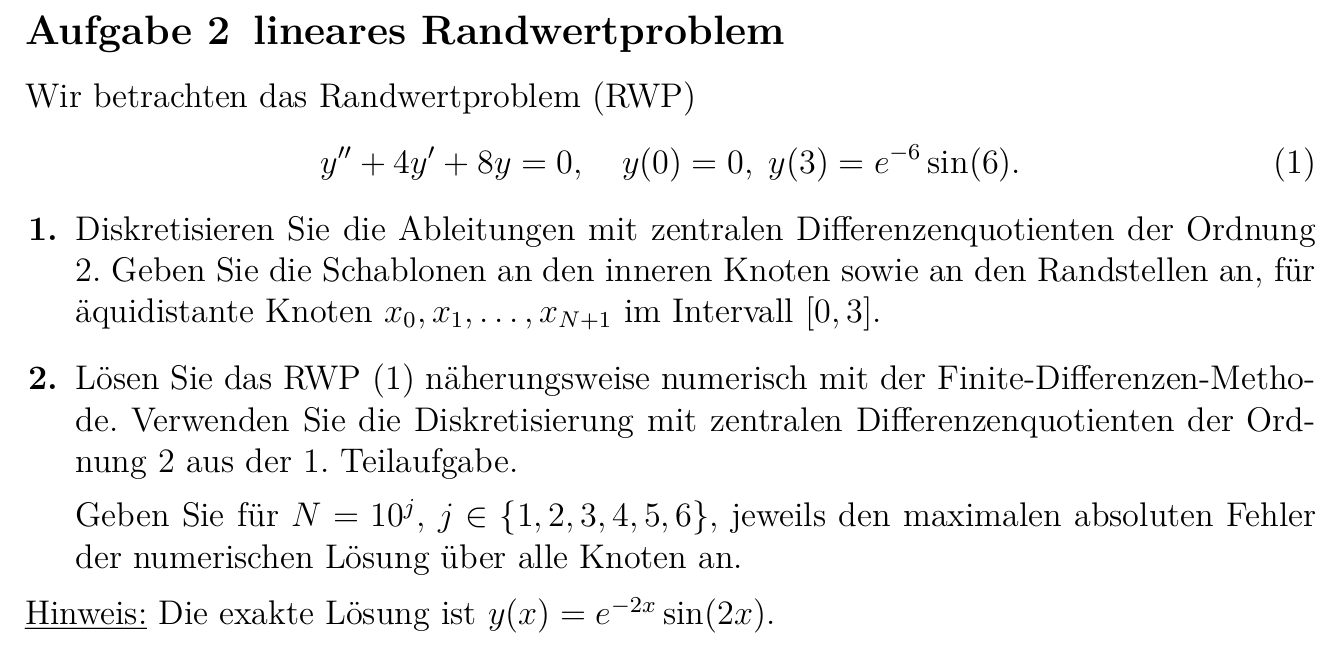

In [3]:

#exakte Lösung aus der Aufgabe
def exakte_loesung(x):
    return np.exp(-2*x) * np.sin(2*x)

# Funktion zur Berechnung der numerischen Lösung mittels RWP
def loese_rwp(N):
    # Schrittweite berechnen
    h = 3 / (N+1) # Intervall [0,3] in N+1 Teile teilen

    # Koeffizienten aus der Finite-Differenzen-Methode
    a = 1 / h**2 - 2/h
    b = -2/h**2 + 8
    c = 1/h**2 + 2/h

    # Randwerte 
    y0 = 0
    yN1 = np.exp(-6) * np.sin(6)

    # Aufbau der Tridiagonalen Matrix für y_1, ..., y_N
    lower = a * np.ones(N - 1)  # untere Nebendiagonale, Länge N-1
    mean = b * np.ones(N)       # Hauptdiagonale, Länge N
    upper = c * np.ones(N - 1)  # obere Nebendiagonale, Länge N-1

    # rechte Seite = r des linearen Gleichungssystems
    r = np.zeros(N)

    # Randwerte in die rechte Seite einbeziehen
    r[0] -= a*y0   # erster Eintrag der rechten Seite - linke Randbedingung
    r[-1] -= c*yN1     # letzter Eintrag der rechten Seite - rechte Randbedingung

    # numerische Lösung des linearen Gleichungssystems mit der Thomas-Algorithmus
    y_inner = nu.thomas_algorithmus(lower, mean, upper, r)

    # Gitterpunkte inklusive Randpunkte erzeugen
    x = np.linspace (0, 3, N+2) # N innere Punkte + 2 Randpunkte = N+2 Punkte insgesamt
    y = np.concatenate([[y0], y_inner, [yN1]])  # numerische Lösung inklusive Randwerte

    return x,y

Errors = [] # Liste zur Speicherung der Fehler für verschiedene N

# Aufgabe: N = 10^j für j = 1,...,6
for j in range(1, 7):
    N = 10**j   # Anzahl der inneren Punkte
    x, y_num = loese_rwp(N) # numerische Lösung berechnen
    err = np.max(np.abs(y_num - exakte_loesung(x))) # maximaler Fehler berechnen
    print(err)  # Fehler ausgeben
    Errors.append(err)  # Fehler in die Liste aufnehmen

print(Errors)   # Fehlerliste ausgeben


3.024482492821327
0.00613593786970601
6.155913915861788e-05
6.165922525891432e-07
5.971168393070769e-09
9.106846388107215e-09
[3.024482492821327, 0.00613593786970601, 6.155913915861788e-05, 6.165922525891432e-07, 5.971168393070769e-09, 9.106846388107215e-09]


Aufgabe 3 - lineare Ausgleichsrechnung
![Serie15_Aufgabe 3a.png](<attachment:Serie15_Aufgabe 3a.png>)
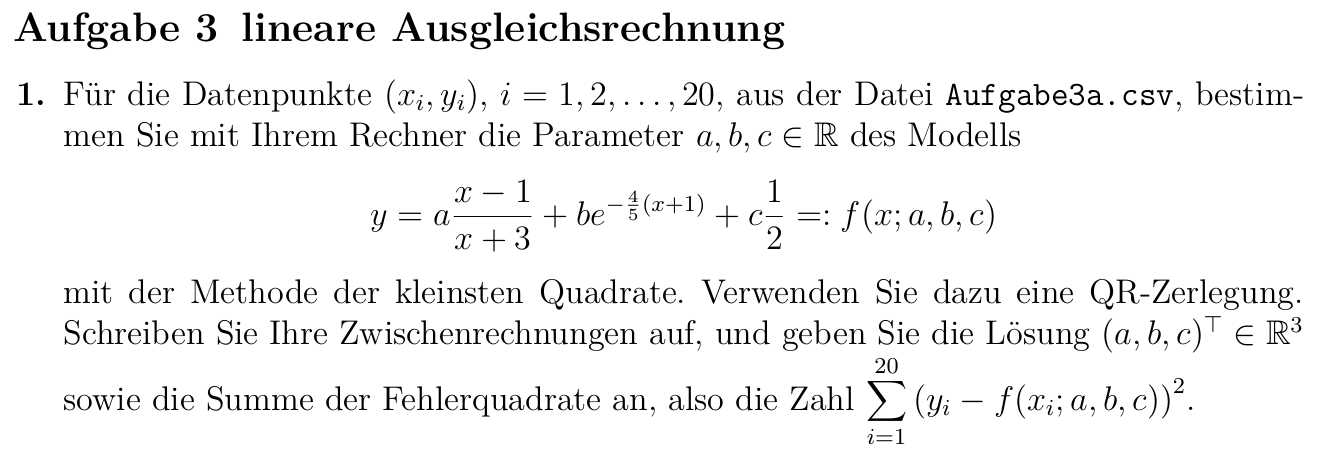

In [4]:
# Datenpunkte aus der Datei einlesen
data = np.genfromtxt("Aufgabe3a.txt", delimiter=",") # WICHTIG: Dateityp muss stimmen!!!
xi = data[0]  # x-Werte
yi = data[1]  # y-Werte

# Matrix A aufbauen
A = np.zeros((len(xi), 3))

# Spalten von A abfüllen
A[:, 0] = (xi - 1) / (xi + 3)       # Spalte 1
A[:, 1] = np.exp(-4/5 * (xi + 1))   # Spalte 2
A[:, 2] = 0.5                       # Spalte 3

# Lineares Ausgleichsproblem lösen
p = nu.lstsq(A, yi) # p enthält die Koeffizienten a, b, c

# Zuweisung der Koeffizienten a, b, c
a = p[0]
b = p[1]
c = p[2]

# berechnete Werte für die Datenpunkte
y = A @ p

# Fehlerquadratsumme berechnen
fehlerquadratsumme = np.sum((y - yi)**2)

print("a =", a)
print("b =", b)
print("c =", c)
print("Fehlerquadratsumme =", fehlerquadratsumme)




a = 3.1841954489444886
b = 4.246461635980066
c = -1.0803741364631922
Fehlerquadratsumme = 0.030274187753976594


![Serie15_Aufgabe 3b.png](<attachment:Serie15_Aufgabe 3b.png>)

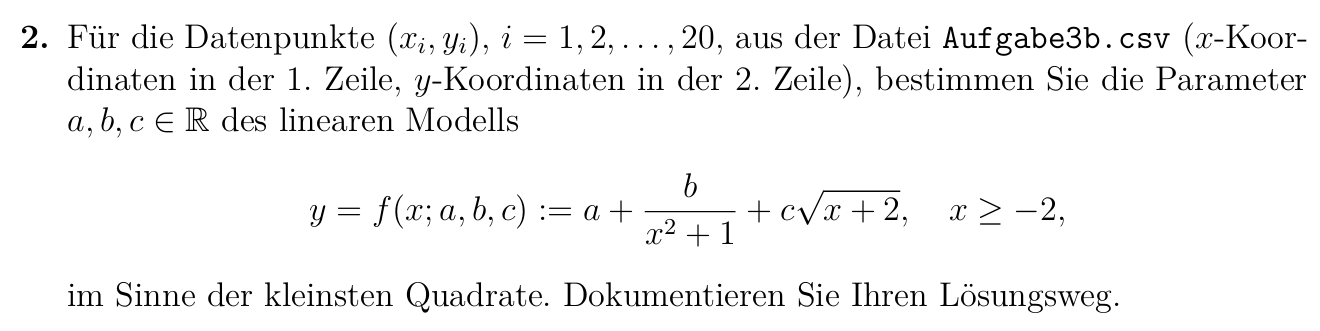

In [5]:
data = np.genfromtxt("Aufgabe3b.txt", delimiter=",") # WICHTIG: Dateityp muss stimmen!!!
xi = data[0]  # x-Werte
yi = data[1]  # y-Werte

# Matrix A aufbauen
A = np.zeros((len(xi), 3))

# Spalten von A abfüllen
A[:, 0] = 1                # Spalte 1
A[:, 1] = (1 / (xi**2 +1)) # Spalte 2
A[:, 2] = np.sqrt(xi + 2)  # Spalte 3

# Lineares Ausgleichsproblem lösen
p = nu.lstsq(A, yi) # p enthält die Koeffizienten a, b, c

# Zuweisung der Koeffizienten a, b, c
a = p[0]
b = p[1]
c = p[2]

# berechnete Werte für die Datenpunkte
y = A @ p

# Fehlerquadratsumme berechnen
fehlerquadratsumme = np.sum((y - yi)**2)

print("a =", a)
print("b =", b)
print("c =", c)
print("Fehlerquadratsumme =", fehlerquadratsumme)

a = 3.8857976366888005
b = -5.239809578451579
c = 1.157353390260682
Fehlerquadratsumme = 1.211562280122071


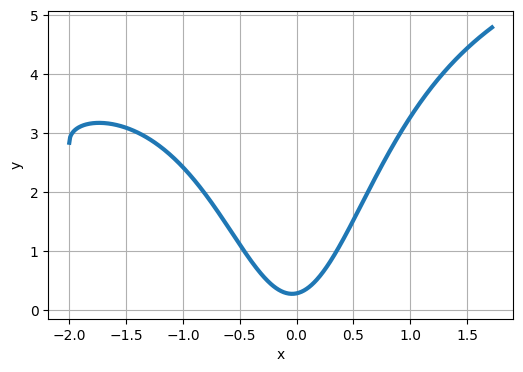

In [6]:
# Feines x-Gitter für die Ausgleichsfunktion
x_plot = np.linspace(-2, max(xi), 500)

# Modellfunktion
y_plot = (
    a
    + b / (x_plot**2 + 1)
    + c * np.sqrt(x_plot + 2)
)

# Plot
plt.figure(figsize=(6,4))

plt.scatter(xi, yi, s=80, facecolors='none')
plt.plot(x_plot, y_plot, linewidth=3)

plt.xlabel("x")
plt.ylabel("y")
plt.grid()

plt.show()

Aufgabe 4 - Lineare Ausgleichsrechnung
![Serie15_Aufgabe 4.png](<attachment:Serie15_Aufgabe 4.png>)
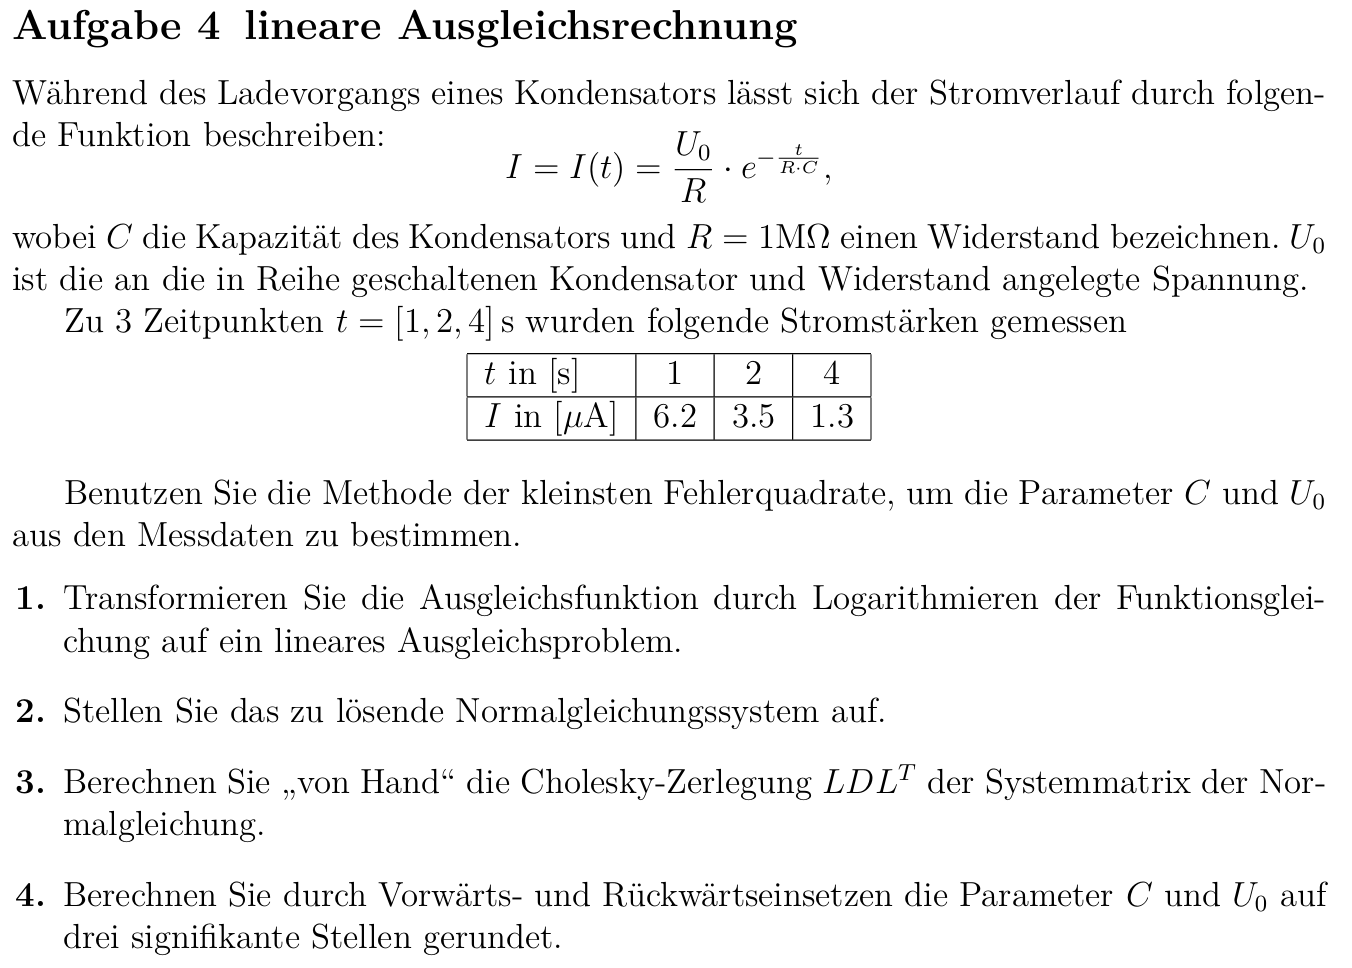

In [7]:
# gegebene Daten einlesen
t = np.array([1, 2, 4])
I = np.array([6.2, 3.5, 1.3])

R = 1e6 # Widerstand = 10 MOhm

# Logarithmieren
# Modell: I = U0/R * exp(-t/(R*C))
# ln(I) = ln(U0/R) - 1/(R*C) * t

z = np.log(I * 1e-6)   # Strom in Ampere umrechnen

# lineares Ausgleichsproblem z = p0 + p1*t
# Matrix A aufbauen
A = np.zeros((len(t), 2))
A[:, 0] = 1
A[:, 1] = t

# Systemmatrix berechnen M = A^T * A
M = A.T @ A     # @ ist der Matrixmultiplikationsoperator in Python

# rechte Seite berechnen b = A^T * z
b = A.T @ z

print("Systemmatrix M:")
print(M)
print("rechte Seite b:")
print(b)

# Cholesky-Zerlegung durchführen
L, D = nu.cholesky2(M) # L ist die untere Dreiecksmatrix, D ist die Diagonalmatrix

print("L:")
print(L)
print("D:")
print(D)

# 1. Vorwärtseinsetzen: L z = b
z1 = nu.fsub(L, b)

# 2. Diagonalsystem lösen: D w = z1
w = nu.dsolve(D, z1)

# 3. Rückwärtseinsetzen: L.T p = w
p = nu.bsub(L.T, w)

p0 = p[0]
p1 = p[1]

# Rückrechnung auf U0 und C
U0 = R * np.exp(p0)
C = -1 / (R * p1)

print("p0 =", p0)
print("p1 =", p1)
print("U0 =", U0)
print("C =", C)

Systemmatrix M:
[[ 3.  7.]
 [ 7. 21.]]
rechte Seite b:
[-38.10685515 -91.32904162]
L:
[[1.         0.        ]
 [2.33333333 1.        ]]
D:
[[3.         0.        ]
 [0.         4.66666667]]
p0 = -11.495761913899287
p1 = -0.517081343883008
U0 = 10.17311691136538
C = 1.933931695331585e-06


Aufgabe 5 - nichtlineare Gleichungssysteme
![Serie15_Aufgabe 5.png](<attachment:Serie15_Aufgabe 5.png>)
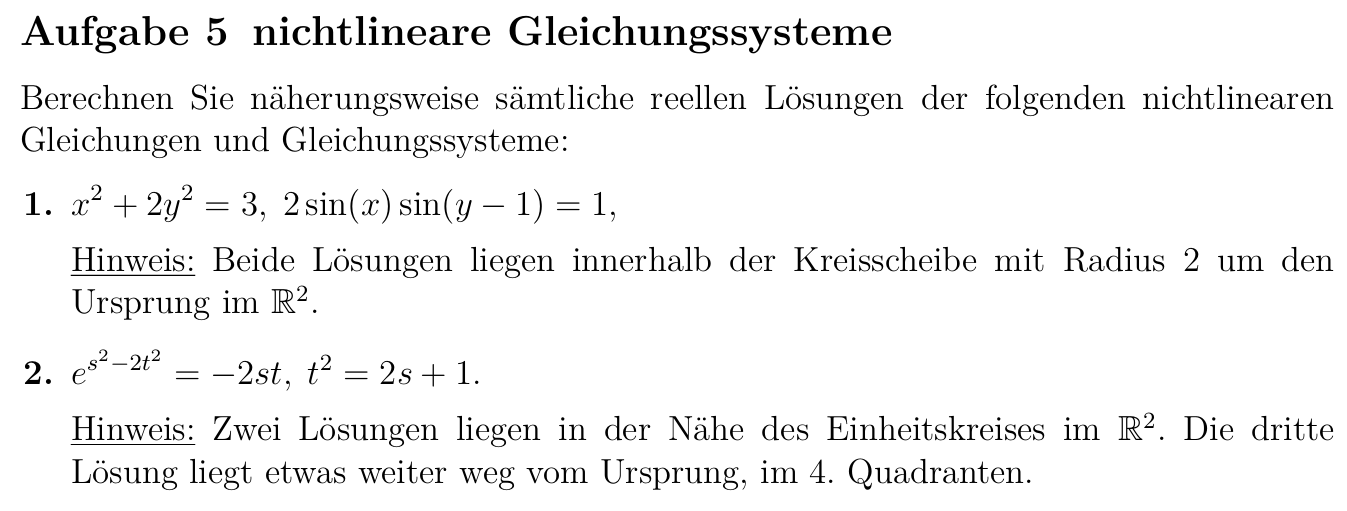

In [8]:
# Funktion f(x,y)
def f(v):   # v ist ein Vektor mit 2 Komponenten: v[0] = x, v[1] = y
    x = v[0]
    y = v[1]

    return np.array([
        x**2 + 2*y**2 - 3,
        2*np.sin(x)*np.sin(y - 1) - 1
    ])

# Jacobimatrix
def J(v):   # v ist ein Vektor mit 2 Komponenten: v[0] = x, v[1] = y
    x = v[0]
    y = v[1]

    return np.array([
        [2*x, 4*y],
        [2*np.cos(x)*np.sin(y - 1), 2*np.sin(x)*np.cos(y - 1)]
    ])

# Newton-Verfahren für Systeme
def newton_system(f, J, x0, tol=1e-10, maxit=50):
    x = np.array(x0, dtype=float)

    for k in range(maxit):
        delta = np.linalg.solve(J(x), -f(x))    # lineares Gleichungssystem J(x) delta = -f(x) lösen
        x = x + delta                           # Update der Lösung

        if np.linalg.norm(delta) < tol:         # Konvergenztest: wenn die Änderung klein genug ist,
            break

    return x

loesungen = []  # Liste zur Speicherung der gefundenen Lösungen

# Startewerte für die Suche nach Lösungen
startwerte = [
    [-1, 1],
    [1, 1]
]

for x0 in startwerte:
    sol = newton_system(f, J, x0)
    loesungen.append(sol)

print(loesungen)

[array([-1.59575261,  0.47622138]), array([ 4.42958481, -1.39534247])]


Aufgabe 5b - nicht lineare Gleichungssysteme

In [9]:
# Funktion f(x,y)
def f(v):   # v ist ein Vektor mit 2 Komponenten: v[0] = x, v[1] = y
    s = v[0]
    t = v[1]

    return np.array([
        np.exp(s**2 - 2*t**2) + 2*s*t,
        t**2 - 2*s - 1,
    ])

# Jacobimatrix
def J(v):   # v ist ein Vektor mit 2 Komponenten: v[0] = x, v[1] = y
    s = v[0]
    t = v[1]

    return np.array([
        [2*s*np.exp(s**2 - 2*t**2) + 2*t, 2*s - 4*t*np.exp(s**2 - 2*t**2)],
        [-2, 2*t]
    ])

def newton_system(f, J, x0, maxit=20):
    x = np.array(x0, dtype=float)

    for k in range(maxit):
        delta = np.linalg.solve(J(x), -f(x))
        x = x + delta

    return x

loesungen = []  # Liste zur Speicherung der gefundenen Lösungen

startwerte = [
    [1, 1],
    [-1, -1],
    [-2, -2]
]

for x0 in startwerte:
    sol = newton_system(f, J, x0)
    loesungen.append(sol)

print(loesungen)




[array([-0.15611105,  0.82932376]), array([ 0.05235878, -1.05105545]), array([-0.18588911,  0.79260442])]


Aufgabe 6 - nichtlineare Ausgleichsrechnung
![Serie15_Aufgabe 6.png](<attachment:Serie15_Aufgabe 6.png>)
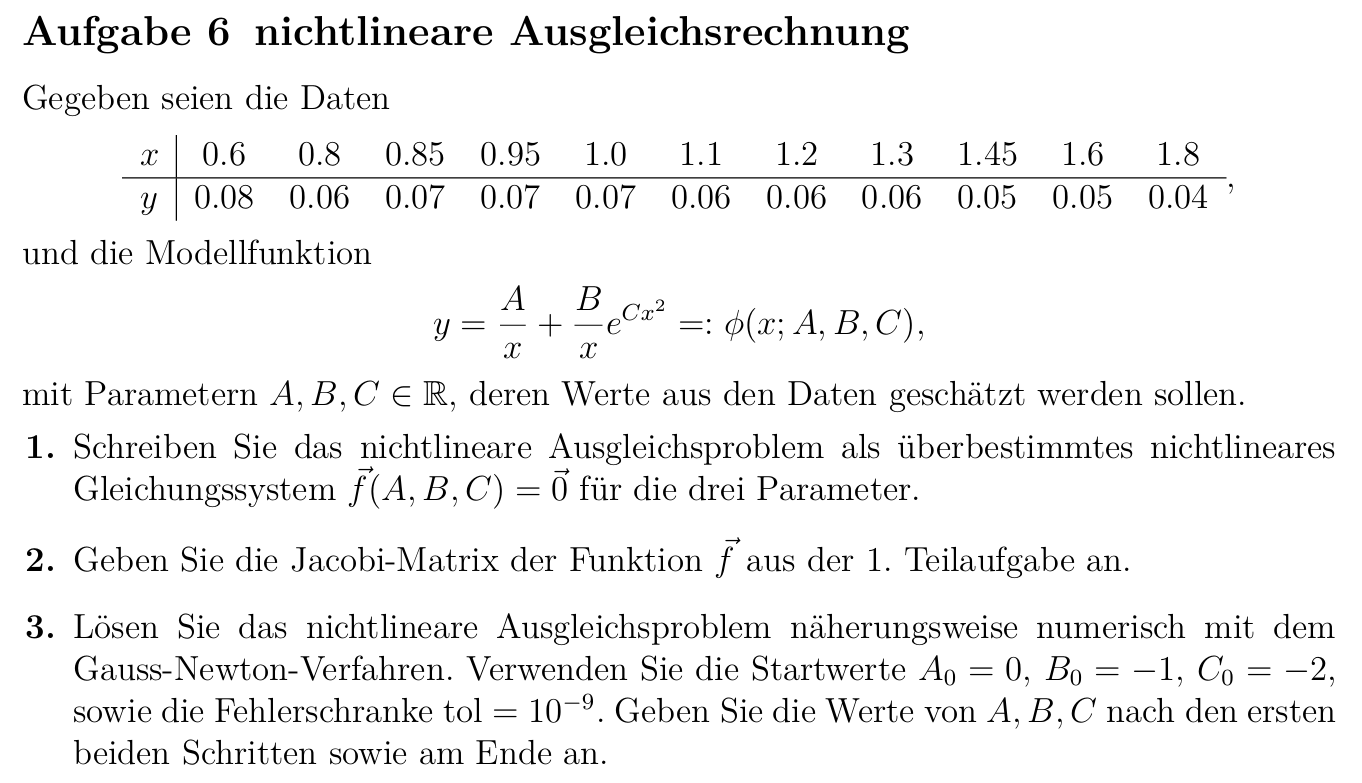

In [10]:
# Daten aus Aufgabe abfüllen
x = np.array([0.6, 0.8, 0.85, 0.95, 1.0, 1.1, 1.2, 1.3, 1.45, 1.6, 1.8])
y = np.array([0.08, 0.06, 0.07, 0.07, 0.07, 0.06, 0.06, 0.06, 0.05, 0.05, 0.04])

# Residuenfunktion f(p) definieren
def f(p):
    A, B, C = p
    return y - A/x - B/x * np.exp(C*x**2)
        
def J(p):
    A, B, C = p
    return np.array([
        -1/x, 
        -1/x*np.exp(C*x**2), 
        -B*x*np.exp(C*x**2)
    ]).T # Transponieren, damit die Dimensionen passen

p = np.array([0, -1, -2], dtype = float) # Startwerte für A, B, C
tol = 1e-9

for k in range(100):
    # Gauss-Newton-Schritt (für Ausgabe der Zwischenresultate)
    delta = nu.lstsq(J(p), -f(p)) # lineares Ausgleichsproblem J(p) delta = -f(p) lösen
    p = p + delta # Update der Parameter

# Funktion führt intern bereits alle Iterationen aus bis zum Ende und gibt
# nur das Endergebnis zurück
# p = nu.gauss_newton(f, J, startwerte, maxit=100)

    # Ausgabe nach den ersten beiden Schritten
    if k == 0:
        print("Nach Schritt 1:", p)

    if k == 1:
        print("Nach Schritt 2:", p)

    if np.linalg.norm(delta) < tol:
        print("Ende:", p)
        print("Iterationen:", k+1)
        break

   
 

Nach Schritt 1: [ 0.07933087 -0.04330631 -1.93494659]
Nach Schritt 2: [ 0.07940436 -0.044858   -0.61573187]
Ende: [ 0.07921336 -0.05270781 -1.31018325]
Iterationen: 22


Aufgabe 7 - gDgl 1. Ordnung
![Serie15_Aufgabe 7.png](<attachment:Serie15_Aufgabe 7.png>)
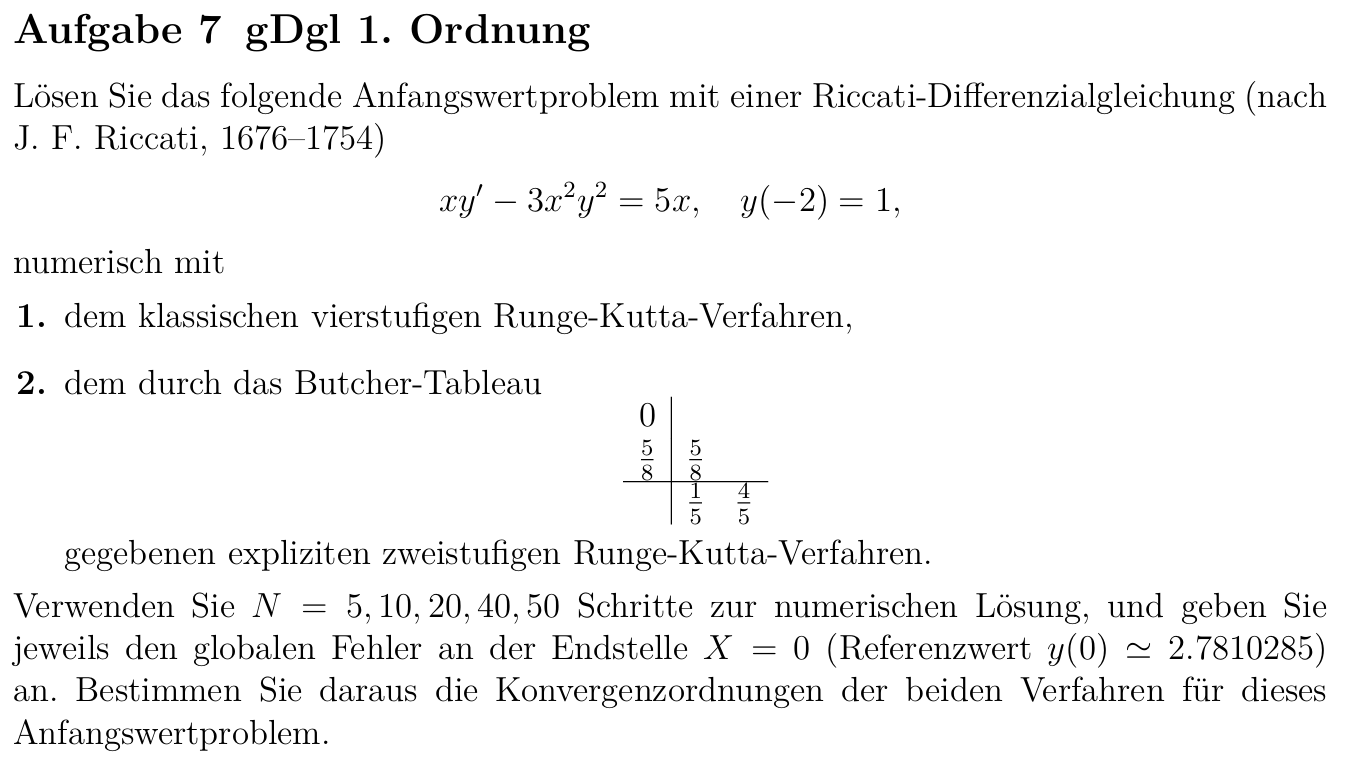

In [11]:
# umgewandelte Differentialgleichung (y' = f(x,y)
def f(x, y):
    return 5 + 3*x*y**2

# Anfangs- und Endwerte sowie Referenzlösung
x0 = -2  # y(-2) = 1
y0 = 1   # y(-2) = 1
xn = 0  
y_ref = 2.7810285

N_werte = [5, 10, 20, 40, 50]   # Schritte gemäss Aufgabenstellung

for N in N_werte:
    h = (xn - x0) / N  # Schrittweite
    
    x, y = nu.RK4(f, x0, y0, xn, h) # RK4-Verfahren anwenden

    fehler = abs(y[-1] - y_ref) # Fehler am Endpunkt berechnen

    print(f"N={N}, y({xn})={y[-1]:.7f}, Fehler={fehler:.2e}")

# 2. Teilaufgabe) Zweistufiges Rungekutta verfahren

def Runge(f, x0, y0, xn, h):
    n = int((xn - x0) / h)
    x = [x0]
    y = [y0]
    for k in range(n):
        r1 = f(x[-1], y[-1])
        r2 = f(x[-1] + 5/8*h, y[-1] + 5/8*h*r1)
        y.append(y[-1] + h * (1/5*r1 + 4/5*r2))
        x.append(x[-1] + h)
    return np.array(x), np.array(y)

print("RK2 speziell")

for N in N_werte:
    x, y = Runge(f, x0, y0, xn, (xn - x0) / N)
    y_end = y[-1]
    fehler = abs(y_end - y_ref)
    print(f"N={N}, y({xn})={y_end:.7f}, Fehler={fehler:.2e}")



N=5, y(0)=2.7167237, Fehler=6.43e-02
N=10, y(0)=2.7806723, Fehler=3.56e-04
N=20, y(0)=2.7810187, Fehler=9.78e-06
N=40, y(0)=2.7810283, Fehler=1.55e-07
N=50, y(0)=2.7810285, Fehler=1.38e-08
RK2 speziell
N=5, y(0)=-8.1127474, Fehler=1.09e+01
N=10, y(0)=2.8108700, Fehler=2.98e-02
N=20, y(0)=2.7862685, Fehler=5.24e-03
N=40, y(0)=2.7824385, Fehler=1.41e-03
N=50, y(0)=2.7819482, Fehler=9.20e-04


Aufgabe 8 - lineare gDgl 2. Ordnung
![Serie15_Aufgabe 8.png](<attachment:Serie15_Aufgabe 8.png>)
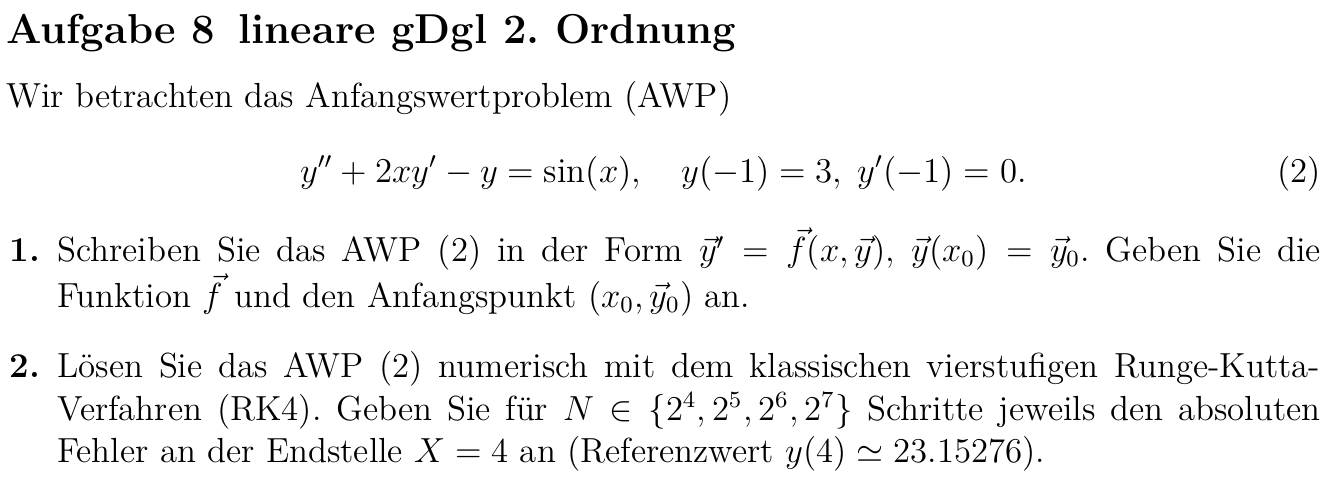

In [12]:

def f(x, y):
    # Zustandsvektor zerlegen
    y1 = y[0]   # entspricht y
    y2 = y[1]   # entspricht y'

    #rechte Seite des Systems
    return np.array([
        y2,
        np.sin(x) - 2*x*y2 + y1
    ])

# Anfangswerte
x0 = -1
y0 = np.array([3, 0], dtype=float)

xn = 4  # Endpunkte gemäss Aufgabe
y_ref = 23.15276    # Referenzwert gemäss Aufgabe

N_werte = [2**4, 2**5, 2**6, 2**7]  # N-Werte gemäss Aufgabe


for N in N_werte:
    h = (xn - x0) / N   # Schrittweite

    x, y = nu.RK4(f, x0, y0, xn, h) # Aufruf RK4-Funktion

    y_end = y[-1, 0]    # letzte Zeile = Lösung am Endpunkt
    fehler = abs(y_end - y_ref) # absoluter Fehler

    print(f"N={N}, y(4)={y_end:.8f}, Fehler={fehler:.2e}")

N=16, y(4)=23.12736928, Fehler=2.54e-02
N=32, y(4)=23.15081085, Fehler=1.95e-03
N=64, y(4)=23.15262409, Fehler=1.36e-04
N=128, y(4)=23.15275145, Fehler=8.55e-06


Aufgabe 9 - Systeme von linearen gDgln
![Serie15_Aufgabe 9.png](<attachment:Serie15_Aufgabe 9.png>)
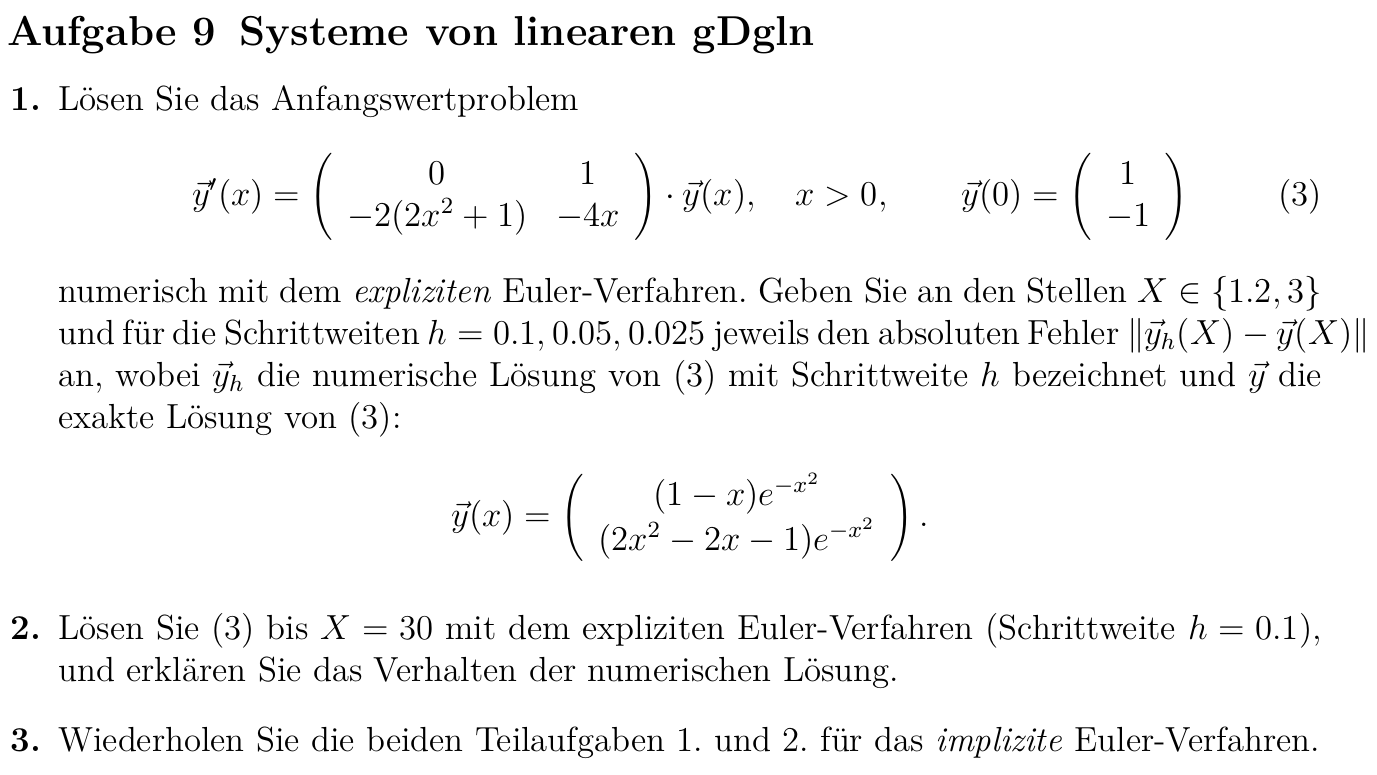

In [13]:
def f(x, y):
    y1 = y[0]
    y2 = y[1]

    return np.array([
        y2,
        -2*(2*x**2 + 1)*y1 - 4*x*y2
    ])

def y_exakt(x):
    return np.array([
        (1 - x)*np.exp(-x**2),
        (2*x**2 - 2*x - 1)*np.exp(-x**2)
    ])

x0 = 0
y0 = np.array([1, -1], dtype=float)

X_werte = [1, 2, 3]
h_werte = [0.1, 0.05, 0.025]

for h in h_werte:
    print("h =", h)

    for X in X_werte:
        x, y = nu.eulerExplizit(f, x0, y0, X, h)

        y_num = y[-1]
        y_ref = y_exakt(X)

        fehler = np.linalg.norm(y_num - y_ref)

        print("X =", X, "Fehler =", fehler)

    print()

h = 0.1
X = 1 Fehler = 0.06794388083535467
X = 2 Fehler = 0.012708359212980249
X = 3 Fehler = 0.0013739951196079794

h = 0.05
X = 1 Fehler = 0.032439760178935795
X = 2 Fehler = 0.005126102240282998
X = 3 Fehler = 0.0009555326497727425

h = 0.025
X = 1 Fehler = 0.015905204413209813
X = 2 Fehler = 0.002339162470989988
X = 3 Fehler = 0.0005460439855631108



In [14]:
h = 0.1
X = 30

x, y = nu.eulerExplizit(f, x0, y0, X, h)

print(y[-1])

[ 7.85717102e+53 -4.51697825e+55]


In [15]:
def euler_implizit_system(f_matrix, x0, y0, xn, h):
    n = int((xn - x0) / h)

    x = [x0]
    y = [y0]

    for k in range(n):
        x_next = x[-1] + h

        A = f_matrix(x_next)

        y_next = np.linalg.solve(
            np.eye(2) - h*A,
            y[-1]
        )

        x.append(x_next)
        y.append(y_next)

    return np.array(x), np.array(y)

def A(x):
    return np.array([
        [0, 1],
        [-2*(2*x**2 + 1), -4*x]
    ])

for h in h_werte:
    print("h =", h)

    for X in X_werte:
        x, y = euler_implizit_system(A, x0, y0, X, h)

        y_num = y[-1]
        y_ref = y_exakt(X)

        fehler = np.linalg.norm(y_num - y_ref)

        print("X =", X, "Fehler =", fehler)

    print()

    h = 0.1
X = 30

x, y = euler_implizit_system(A, x0, y0, X, h)

print(y[-1])

h = 0.1
X = 1 Fehler = 0.09589444351855424
X = 2 Fehler = 0.041933938237217194
X = 3 Fehler = 0.000340783669824709

h = 0.05
X = 1 Fehler = 0.05032938418989635
X = 2 Fehler = 0.020366778737836013
X = 3 Fehler = 0.0004314100207772121

h = 0.025
X = 1 Fehler = 0.025768552419635674
X = 2 Fehler = 0.009969220781013161
X = 3 Fehler = 0.0002692084414249868

[-5.89889135e-160  3.34412516e-158]


Aufgabe 10
-> auf Papier gelöst

Aufgabe 11
![Serie15_Aufgabe 11.png](<attachment:Serie15_Aufgabe 11.png>)
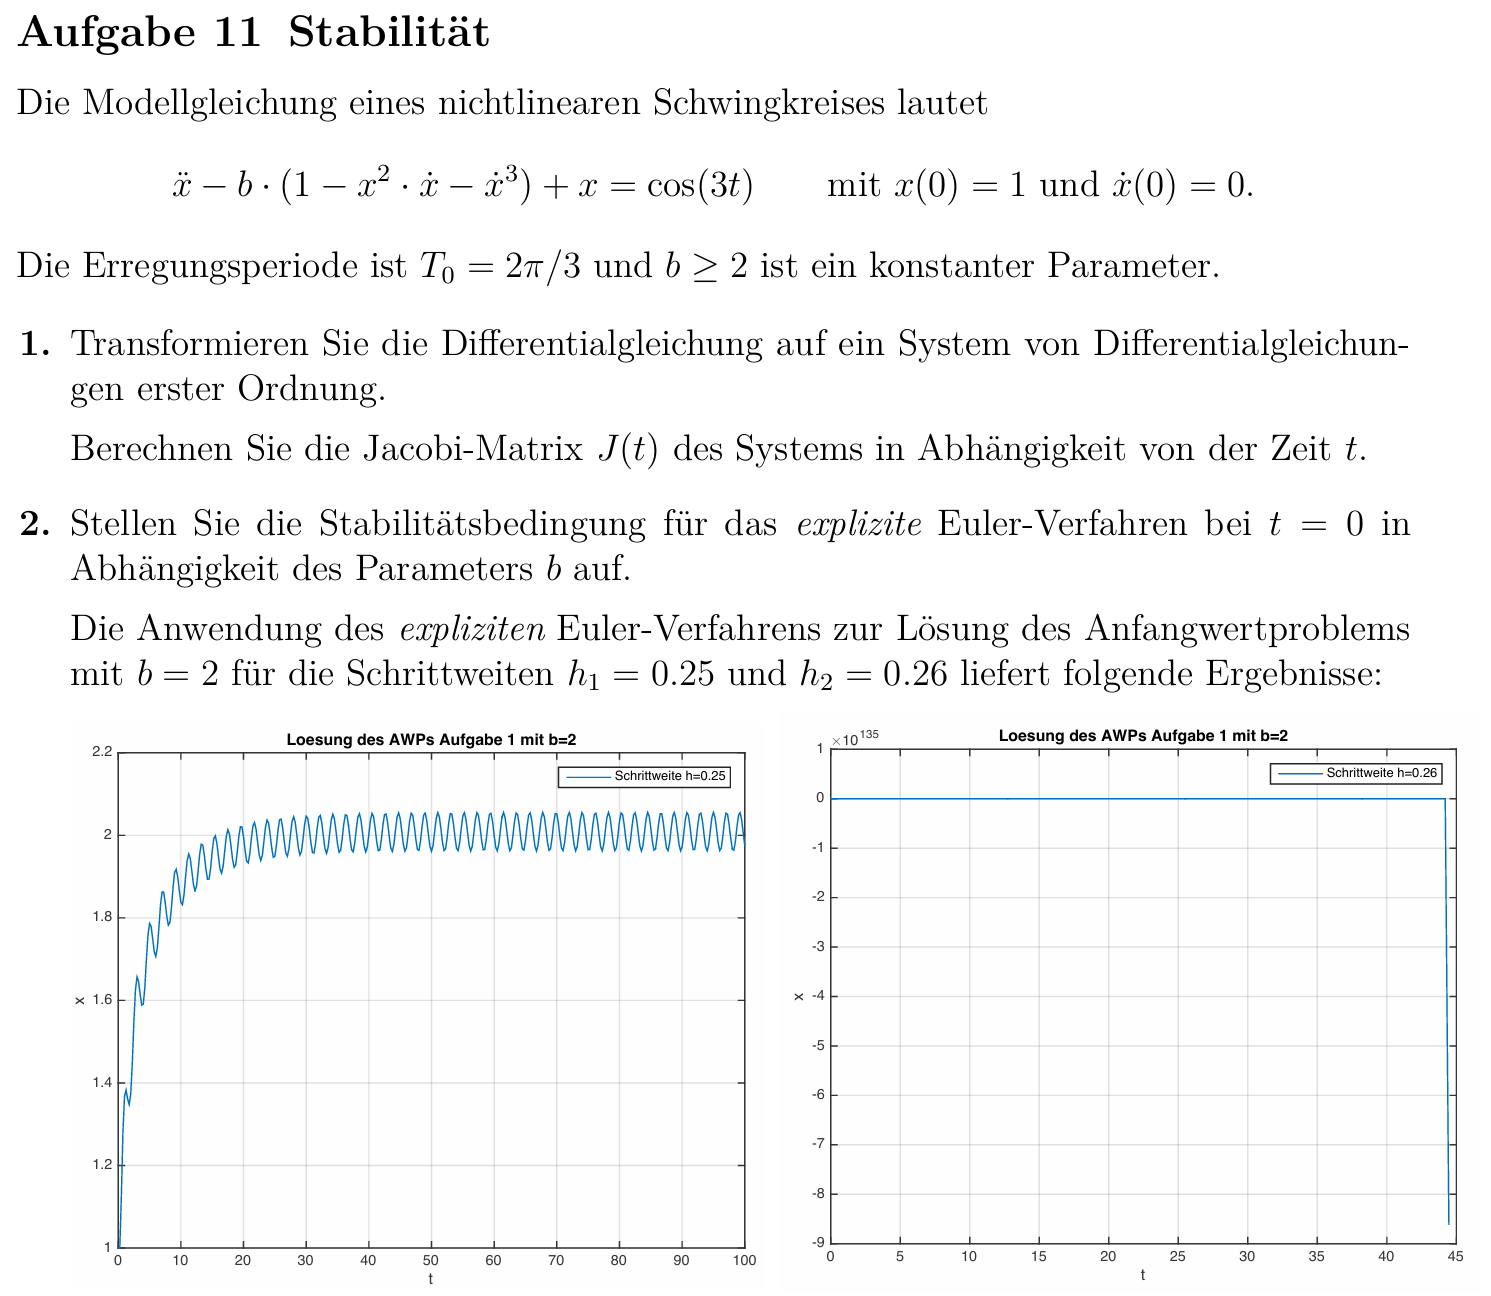

C:\Users\nikgr_xfg11sc\AppData\Local\Temp\ipykernel_5156\3448874898.py:9: RuntimeWarning: overflow encountered in scalar power
  np.cos(3*t) + b*(1-x**2 * v -v**3) - x
c:\Users\nikgr_xfg11sc\OneDrive\Nik Grabo\ZHAW\4. Semester\Numerik\Prüfungsvorbereitung\numerik.py:622: RuntimeWarning: invalid value encountered in add
  y.append(y[-1] + h * f(x[-1], y[-1]))


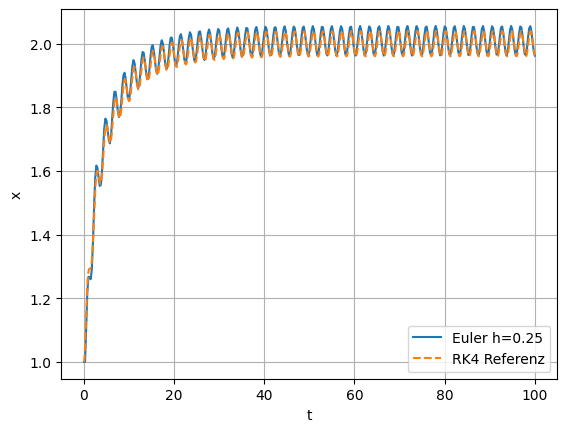

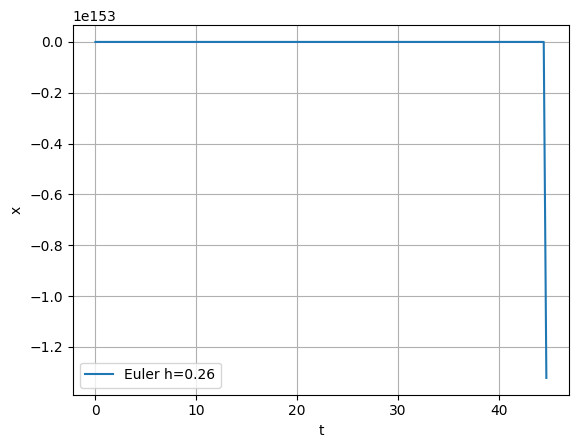

In [17]:
# Konstante
b = 2   # b >= 2

def f(t,y):
    x = y[0]    # x = y1
    v = y[1]    # v = y2
    return np.array([
        v,
        np.cos(3*t) + b*(1-x**2 * v -v**3) - x
    ])

y0 = np.array([1, 0])   # Startwerte x(0) = 1 / x'(0) = 0

# Jacobimatrix
def J(t, y):
    x = y[0]
    v = y[1]
    return np.array([
        [0, 1],
        [-2*b*x*v - 1, -b*(x**2 + 3*v**2)]
    ])

# Euler mit h = 0.25
t1, y1 = nu.eulerExplizit(f, 0, y0, 100, 0.25)

# Euler mit h = 0.26
t2, y2 = nu.eulerExplizit(f, 0, y0, 45, 0.26)

# Referenzlösung mit RK4
t_ref, y_ref = nu.RK4(f, 0, y0, 100, 0.01)

plt.figure()
plt.plot(t1, y1[:, 0], label="Euler h=0.25")
plt.plot(t_ref, y_ref[:, 0], "--", label="RK4 Referenz")
plt.xlabel("t")
plt.ylabel("x")
plt.grid()
plt.legend()
plt.show()

plt.figure()
plt.plot(t2, y2[:, 0], label="Euler h=0.26")
plt.xlabel("t")
plt.ylabel("x")
plt.grid()
plt.legend()
plt.show()

Für h=0.25 liefert das explizite Euler-Verfahren eine stabile Lösung, die gut mit der RK4-Referenzlösung übereinstimmt. Für h=0.26 wird die Lösung dagegen instabil und divergiert nach einiger Zeit. Dies zeigt, dass das explizite Euler-Verfahren sehr empfindlich auf die Wahl der Schrittweite reagiert und die Stabilitätsgrenze hier ungefähr bei h≈0.25 liegt.

Aufgabe 12
![Serie15_Aufgabe 12.png](<attachment:Serie15_Aufgabe 12.png>)
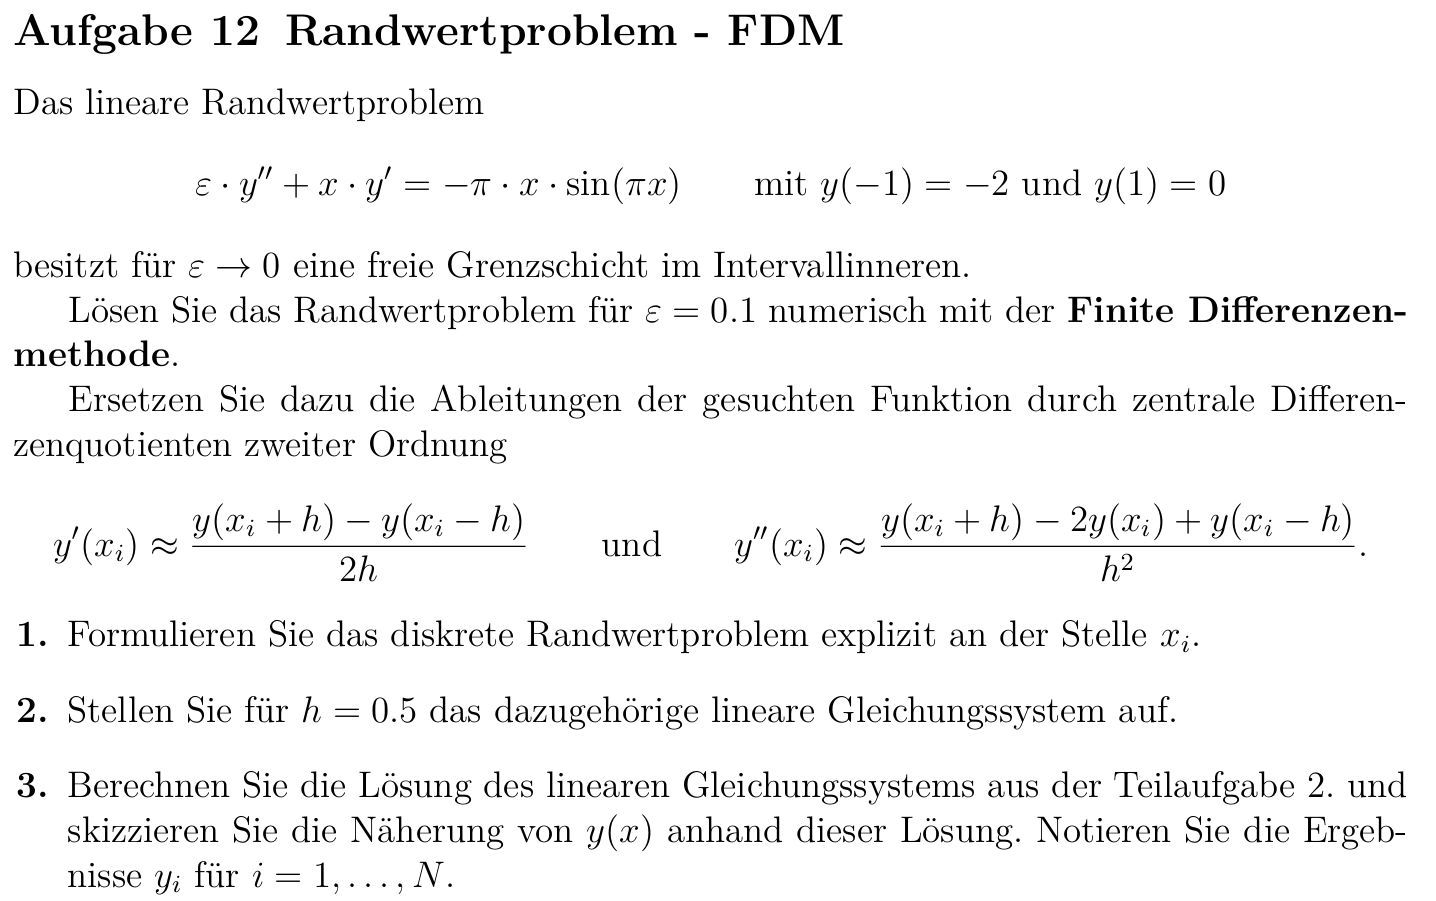

Teilaufgabe 3:
x-Werte:
[-1.  -0.5  0.   0.5  1. ]

Numerische Lösung y_i:
[-2.         -0.37967075  0.74532925  1.87032925  0.        ]


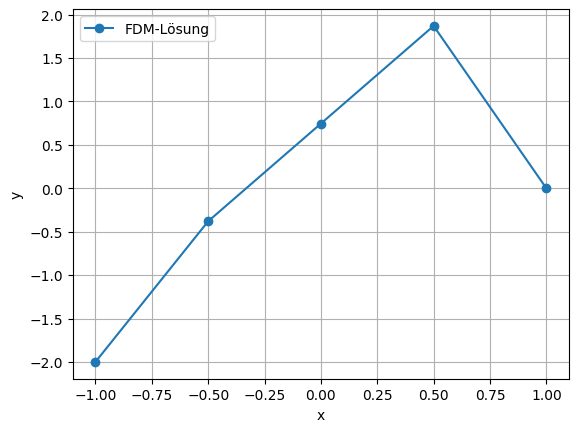

In [ ]:
# Parameter gegeben aus Aufgabe
eps = 0.1
h = 0.5

# Diskretisierung des Intervalls [-1, 1]
x = np.arange(-1, 1 + h, h)
#Anzahl der Intervalle
N = len(x) - 1

# Randwerte
y_links = -2
y_rechts = 0

# Teilaufgabe 2 und 3: LGS aufstellen und lösen

A = np.zeros((N + 1, N + 1))    # linke Seite
b = np.zeros(N + 1)             # rechte Seite

# Randbedingung links
A[0, 0] = 1
b[0] = y_links

# Innere Stützstellen x1, x2, x3
for i in range(1, N):
    xi = x[i]

    A[i, i-1] = eps / h**2 - xi / (2*h)
    A[i, i]   = -2 * eps / h**2
    A[i, i+1] = eps / h**2 + xi / (2*h)

    b[i] = -np.pi * xi * np.sin(np.pi * xi)

# Randbedingung rechts
A[N, N] = 1
b[N] = y_rechts

# Lösung des Gleichungssystems
y = nu.linsolve(A, b)

print("Teilaufgabe 3:")
print("x-Werte:")
print(x)
print()
print("Numerische Lösung y_i:")
print(y)

# Skizze
plt.figure()
plt.plot(x, y, marker="o", label="FDM-Lösung")
plt.xlabel("x")
plt.ylabel("y")
plt.grid()
plt.legend()
plt.show()

Aufgabe 13 
![Serie15_Aufgabe 13.png](<attachment:Serie15_Aufgabe 13.png>)
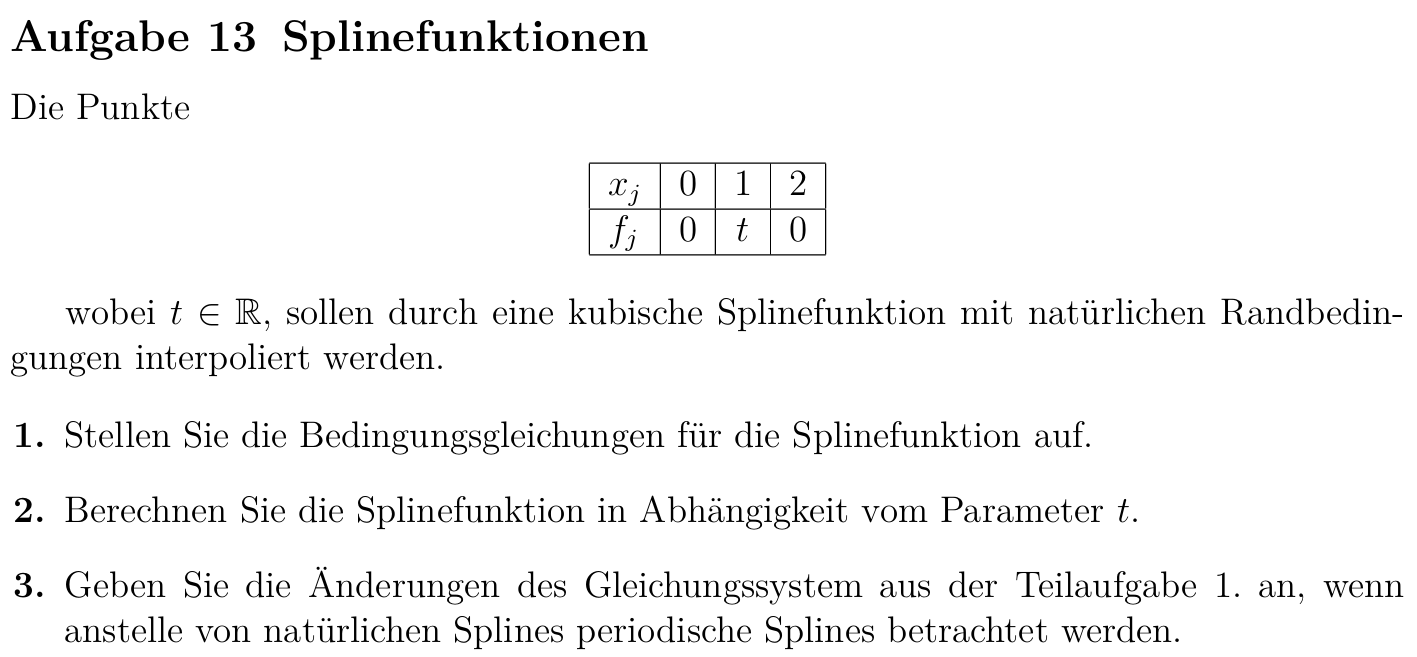

Koeffizienten:
a = [0. 1.]
b = [1.5 0. ]
c = [ 0.  -1.5]
d = [-0.5  0.5]
a1 = 0.5
b1 = -3.0
c1 = 4.5
d1 = -1.0


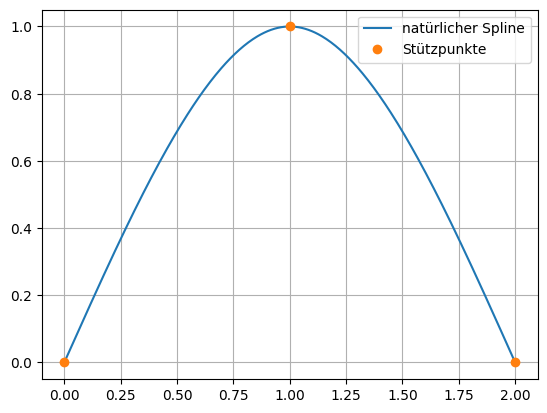

In [23]:
# Stützpunkte
x = np.array([0, 1, 2], dtype=float)

# Parameter
t = 1
f = np.array([0, t, 0], dtype = float) 

# Natürlicher kubischer Spline
a, b, c, d = nu.cubic_spline_natural(x,f)

print("Koeffizienten:")
print("a =", a)
print("b =", b)
print("c =", c)
print("d =", d)

# Intervall [1,2]
# S1(x)=a[1]+b[1](x-1)+c[1](x-1)^2+d[1](x-1)^3
# nach Potenzen von x ausmultiplizieren
a1 = d[1]
b1 = c[1] - 3*d[1]
c1 = b[1] - 2*c[1] + 3*d[1]
d1 = a[1] - b[1] + c[1] - d[1]

print("a1 =", a1)
print("b1 =", b1)
print("c1 =", c1)
print("d1 =", d1)

# Auswertung
x_fine = np.linspace(0, 2, 400)
y_fine = nu.spline_auswerten(x, a, b, c, d, x_fine)

plt.plot(x_fine, y_fine, label="natürlicher Spline")
plt.plot(x, f, "o", label="Stützpunkte")
plt.grid()
plt.legend()
plt.show()